# Tree Counter Dataset Quality Evaluation

## tl;dr
This notebook checks whether `dataset1` is structurally suitable for a first YOLO tree-crown baseline. Run all cells to refresh the evidence before training.

## Context & Methods

The intended unit is one 640 x 640 aerial image with zero or more normalized YOLO bounding boxes. Checks cover image/label pairing, image dimensions, malformed or out-of-range labels, empty labels, duplicate image content and crown-count distribution.

### Key Assumptions
Each non-empty label row represents one visible tree crown and class `0` is the only accepted class. Structural validity does not prove annotation completeness or ecological representativeness.

In [1]:
from pathlib import Path
import hashlib
import statistics

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'tree-counting-model').exists())
dataset_root = project_root / 'tree-counting-model' / 'dataset1'
splits = ('train', 'valid', 'test')
print(f'Dataset: {dataset_root}')

Dataset: /Users/joseph/Desktop/DS Proejct/ai-first-nations/tree-counting-model/dataset1


## Data

### 1. Profile files and annotations
The next cell verifies one-to-one image/label pairing and validates every YOLO row as `class x_center y_center width height` with normalized coordinates.

In [2]:
profiles = {}
all_hashes = {}
all_counts = {}
for split in splits:
    image_dir = dataset_root / split / 'images'
    label_dir = dataset_root / split / 'labels'
    images = sorted(path for path in image_dir.iterdir() if path.suffix.lower() in {'.jpg', '.jpeg', '.png'})
    labels = sorted(label_dir.glob('*.txt'))
    image_stems = {path.stem for path in images}
    label_stems = {path.stem for path in labels}
    invalid_rows = []
    counts = []
    dimensions = set()
    empty_labels = 0
    for image_path in images:
        with Image.open(image_path) as image:
            dimensions.add(image.size)
        digest = hashlib.sha256(image_path.read_bytes()).hexdigest()
        all_hashes.setdefault(digest, []).append(f'{split}/{image_path.name}')
    for label_path in labels:
        rows = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        counts.append(len(rows))
        empty_labels += int(not rows)
        for row_number, row in enumerate(rows, 1):
            parts = row.split()
            valid = len(parts) == 5
            if valid:
                try:
                    class_id, x, y, width, height = map(float, parts)
                    valid = class_id == 0 and 0 <= x <= 1 and 0 <= y <= 1 and 0 < width <= 1 and 0 < height <= 1
                except ValueError:
                    valid = False
            if not valid:
                invalid_rows.append(f'{label_path.name}:{row_number}')
    all_counts[split] = counts
    profiles[split] = {
        'images': len(images), 'labels': len(labels), 'boxes': sum(counts),
        'missing_labels': len(image_stems - label_stems),
        'missing_images': len(label_stems - image_stems),
        'empty_labels': empty_labels, 'invalid_rows': len(invalid_rows),
        'dimensions': sorted(dimensions),
    }
for split, profile in profiles.items():
    print(split, profile)
duplicates = [paths for paths in all_hashes.values() if len(paths) > 1]
print('Duplicate image groups:', len(duplicates))

train {'images': 64, 'labels': 64, 'boxes': 5243, 'missing_labels': 0, 'missing_images': 0, 'empty_labels': 0, 'invalid_rows': 0, 'dimensions': [(640, 640)]}
valid {'images': 18, 'labels': 18, 'boxes': 1524, 'missing_labels': 0, 'missing_images': 0, 'empty_labels': 0, 'invalid_rows': 0, 'dimensions': [(640, 640)]}
test {'images': 9, 'labels': 9, 'boxes': 759, 'missing_labels': 0, 'missing_images': 0, 'empty_labels': 0, 'invalid_rows': 0, 'dimensions': [(640, 640)]}
Duplicate image groups: 0


## Results

### 2. Compare crown-count distributions
A large split shift would make test performance less representative. The table and histogram compare labelled crown counts per image.

train min= 16 median= 77.0 mean= 81.9 max=253
valid min= 22 median= 86.5 mean= 84.7 max=137
test  min=  7 median= 86.0 mean= 84.3 max=175


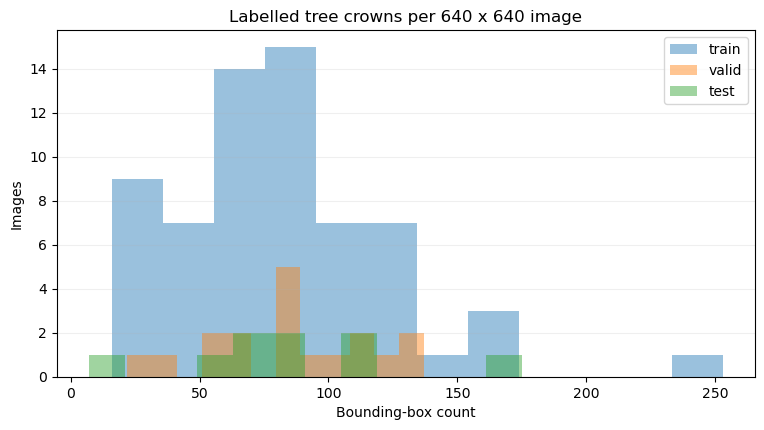

In [3]:
for split, counts in all_counts.items():
    print(f'{split:5} min={min(counts):3d} median={statistics.median(counts):5.1f} mean={statistics.mean(counts):5.1f} max={max(counts):3d}')
plt.figure(figsize=(9, 4.5))
for split, counts in all_counts.items():
    plt.hist(counts, bins=12, alpha=0.45, label=split)
plt.title('Labelled tree crowns per 640 x 640 image')
plt.xlabel('Bounding-box count')
plt.ylabel('Images')
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

### 3. Inspect representative labels
This draws boxes on the median-count training image. It helps catch coordinate conversion errors and obvious systematic annotation problems that file checks cannot detect.

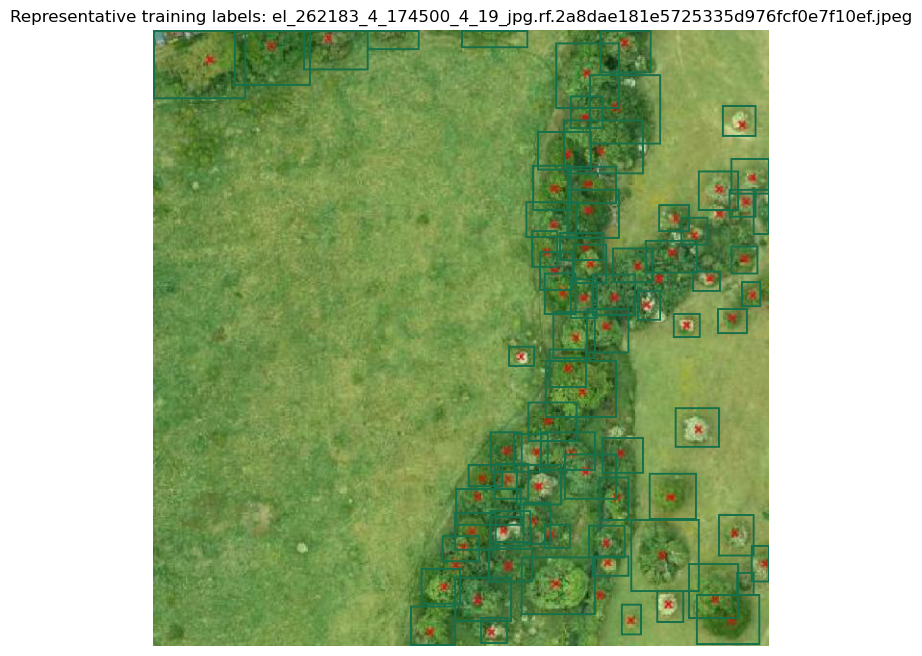

In [4]:
train_labels = sorted((dataset_root / 'train' / 'labels').glob('*.txt'))
selected_label = min(train_labels, key=lambda path: abs(len(path.read_text().splitlines()) - statistics.median(all_counts['train'])))
selected_image = next((dataset_root / 'train' / 'images').glob(selected_label.stem + '.*'))
image = Image.open(selected_image).convert('RGB')
draw = ImageDraw.Draw(image)
for row in selected_label.read_text().splitlines():
    _, x, y, width, height = map(float, row.split())
    x1 = (x - width / 2) * image.width
    y1 = (y - height / 2) * image.height
    x2 = (x + width / 2) * image.width
    y2 = (y + height / 2) * image.height
    draw.rectangle((x1, y1, x2, y2), outline=(22, 112, 74), width=2)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title(f'Representative training labels: {selected_image.name}')
plt.axis('off')
plt.show()

## Takeaways

In [5]:
total_images = sum(profile['images'] for profile in profiles.values())
total_boxes = sum(profile['boxes'] for profile in profiles.values())
total_issues = sum(profile['missing_labels'] + profile['missing_images'] + profile['empty_labels'] + profile['invalid_rows'] for profile in profiles.values())
print(f'PASS: {total_images} images and {total_boxes} labelled crowns are structurally usable.' if total_issues == 0 and not duplicates else 'REVIEW REQUIRED: structural issues were found.')
print('Limitation: only 91 images are available, all at one resolution, and structural checks cannot verify missed or biologically ambiguous crowns.')
print('Decision: suitable for an experimental baseline, with test metrics and visual error analysis required before product claims.')

PASS: 91 images and 7526 labelled crowns are structurally usable.
Limitation: only 91 images are available, all at one resolution, and structural checks cannot verify missed or biologically ambiguous crowns.
Decision: suitable for an experimental baseline, with test metrics and visual error analysis required before product claims.
